In [2]:
import time
from time import perf_counter
import plotnine as p9
from plotnine import geom_bar, ggplot, aes, geom_histogram, geom_smooth, theme_bw, labs
import matplotlib.pyplot as plt
import numpy as np

In [3]:
class Tree:
    def __init__(self):
        self._value = None
        self._data = None
        self.left = None
        self.right = None

    def add(self, key, data):
        if self._value is None:
            self._value = key
            self._data = data
            self.left = Tree()
            self.right = Tree()
            return self

        if self._value == key:
            return self

        if self._value < key:
            self.right.add(key, data)
        else:
            self.left.add(key, data)
        return self
    
    def __contains__(self, patient_id):
        if self._value == patient_id:
           return True
        elif self.left and patient_id < self._value:
            return patient_id in self.left
        elif self.right and patient_id > self._value:
            return patient_id in self.right
        else:
            return False

In [4]:
 my_tree = Tree()
 for patient_id, initials in [(24601, "JV"), (42, "DA"), (7, "JB"), (143, "FR"), (8675309, "JNY")]:
     my_tree.add(patient_id, initials)

In [5]:
print(24601 in my_tree)

True


In [6]:
print(1492 in my_tree)

False


In [7]:
print(7 in my_tree)

True


In [8]:
def has_data(node, data):
    if node is None or node._value is None:
        return False
    if node._data == data:
        return True
    left_result = has_data(node.left, data) if node.left else False
    right_result = has_data(node.right, data) if node.right else False
    return left_result or right_result

In [9]:
has_data(my_tree, 'JV')

True

In [10]:
has_data(my_tree, 'CG')

False

In [11]:
has_data(my_tree, 'JNY')

True

In [12]:
#continue testing with different places on tree

In [27]:
fake_data = {(24601, "JV"), (42, "DA"), (7, "JB"), (143, "FR"), (8675309, "JNY"), (12341235, "CG"), (12398920, "AG"), (14, "CU"), (5, "KG"), (865312, "TN"), (654654, 'MG'), (34567, 'KLG'), (6667, 'RGIII'), (123456, 'Thirty'), (123, 'TS'), (2345674, 'JH'), (1234890, 'UT'), (6574839201, 'JH')}
n_values = [14, 6574839201, 8653121676]
#n_values = [t[0] for t in fake_data]

my_tree = Tree()
for patient_id, initials in fake_data:
    my_tree.add(patient_id, initials)

In [33]:
contains_time1 = []

t1start = perf_counter()
print(14 in my_tree)
t1stop = perf_counter()
total_time = t1stop - t1start
contains_time1.append(total_time)
print("Elapsed time during contains in seconds:", total_time)

t1start = perf_counter()
print(6574839201 in my_tree)
t1stop = perf_counter()
total_time = t1stop - t1start
contains_time1.append(total_time)
print("Elapsed time during contains in seconds:", total_time)

t1start = perf_counter()
print(8653121676 in my_tree)
t1stop = perf_counter()
total_time = t1stop - t1start
contains_time1.append(total_time)
print("Elapsed time during contains in seconds:", total_time)

True
Elapsed time during contains in seconds: 0.00016789999790489674
True
Elapsed time during contains in seconds: 5.7900004321709275e-05
False
Elapsed time during contains in seconds: 5.289999535307288e-05


In [34]:
print(contains_time1)
print(n_values)

[0.00016789999790489674, 5.7900004321709275e-05, 5.289999535307288e-05]
[14, 6574839201, 8653121676]


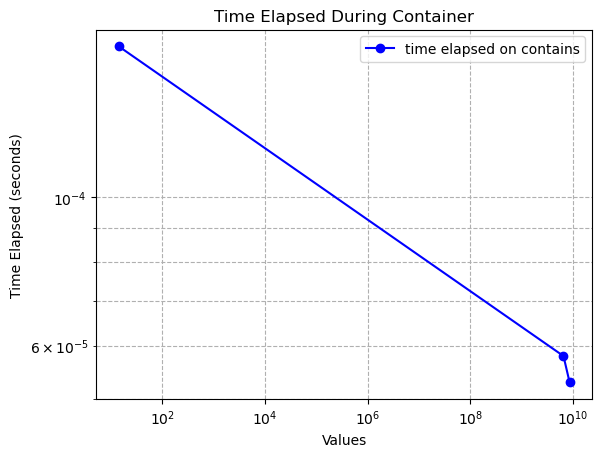

In [35]:
plt.figure()
plt.loglog(n_values, contains_time1, label='time elapsed on contains', marker='o', linestyle='-', color='blue')
#plt.loglog(n_values, data1_time_alg2, label='alg2 on data1', marker='o', linestyle='-', color ='red')

plt.xlabel('Values')
plt.ylabel('Time Elapsed (seconds)')
plt.title('Time Elapsed During Container')
plt.legend()

plt.grid(True, which="both", ls="--")
